In [33]:
import pandas as pd
import sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

In [34]:
from preprocessor import preprocess_tender_data

data = pd.read_csv('/Users/polina/b2b_reccomendation_systems/preprocessed_full.csv')

In [35]:
data = data.drop(columns = ['Unnamed: 0'])

In [36]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler

num = [
    "avg_price_drop",
    "log_cost",
    "log_profit",
    "Снижение на торгах,%",
    'win_rate',  'region_win_rate', 
    'customer_win_rate', 'sphere_win_rate',
    "days_between",
    "region_wins",
    "customer_wins",
    "sphere_wins",
    "total_wins",
    "competitors_per_tender",
    "avg_competitors_in_region",
    "avg_competitors_in_sphere",
    "avg_competitors_in_customer",
    "Обеспечение заявки (руб.)",
    "Обеспечение заявки, %",
    "Обеспечение контракта (руб.)",
    "Обеспечение контракта, %"
]

cat = [
    "Сфера деятельности",
    "Регион поставки",
    "Город поставки",
    "Тип торгов",
    "Уровень",
    "year",
    "month",
    "Сводный риск"
]

binary_features = [
    "РНП ранее", 
    "is_january", 
    "publication_peak_9_11", 
    "app_end_noon_12", 
    "app_start_night_12",
    "trade_end_night_12",
    "is_2019",
    "is_jan_to_april",
    "Статус допуска"
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat),
        ('pass', 'passthrough', binary_features)
    ],
    remainder='drop'
    )

train = data[data['year'].isin(range(2015, 2021))]
test = data[data['year'].isin(range(2021, 2026))]
X_train = train[num + cat + binary_features]
y_train = train["Победитель"]
X_test = test[num + cat + binary_features]
y_test = test["Победитель"]

In [37]:
print(X_test.shape)
print(X_train.shape)

(51991, 38)
(440030, 38)


In [38]:
print(y_train.sum())

199772


In [39]:
#X_train = X_train.sample(n=10000, random_state=42)
#y_train = y_train.sample(n=10000, random_state=42)

In [40]:
X_train['year'].value_counts()

year
2019    347423
2020     57837
2018     28590
2016      2703
2015      1745
2017      1732
Name: count, dtype: int64

In [41]:
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"\n{name} Metrics:")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall:", round(recall_score(y_true, y_pred), 4))
    print("F1-Score:", round(f1_score(y_true, y_pred), 4))
    print("ROC-AUC:", round(roc_auc_score(y_true, y_proba), 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    plt.figure(figsize=(10, 8))
    conf_matrix = confusion_matrix(y_true, y_pred)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Winner', 'Winner'],
                yticklabels=['Not Winner', 'Winner'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def draw_roc_curve(y_test, y_proba, name):
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkcyan', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} ROC curve')
    plt.legend(loc='lower right')
    plt.show()

In [42]:
from sklearn.linear_model import SGDClassifier

In [43]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, random_state=42, stratify = y_train, test_size=0.3)

In [44]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((308021, 38), (132009, 38), (308021,), (132009,))

In [55]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score

def objective(trial):
    loss = trial.suggest_categorical('loss', ['hinge', 'squared_hinge'])
    penalty = trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet'])
    alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)

    l1_ratio = 0.15 # дефолтное если не elasticnet
    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)

    max_iter = trial.suggest_int('max_iter', 500, 5000, step=500)
    learning_rate = trial.suggest_categorical('learning_rate', ['optimal', 'adaptive', 'invscaling'])

    # eta0 используется только если learning_rate 'constant', 'invscaling', or 'adaptive'
    eta0 = 0.0 
    if learning_rate != 'optimal':
        eta0 = trial.suggest_float('eta0', 1e-4, 1e-1, log=True)

    classifier = SGDClassifier(
        loss=loss,
        penalty=penalty,
        alpha=alpha,
        l1_ratio=l1_ratio,
        max_iter=max_iter,
        learning_rate=learning_rate,
        eta0=eta0,
        random_state=42 
    )
    current_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    current_pipeline.fit(X_train, y_train)
    y_pred = current_pipeline.predict(X_val)
    score = f1_score(y_val, y_pred)

    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2025-04-28 19:25:53,812] A new study created in memory with name: no-name-f3c6c968-5c1a-4edd-a297-548f2f865678


[I 2025-04-28 19:25:55,642] Trial 0 finished with value: 0.8845055845443961 and parameters: {'loss': 'squared_hinge', 'penalty': 'elasticnet', 'alpha': 0.0036693034777802004, 'l1_ratio': 0.4139660203287392, 'max_iter': 3500, 'learning_rate': 'optimal'}. Best is trial 0 with value: 0.8845055845443961.
[I 2025-04-28 19:26:03,185] Trial 1 finished with value: 0.9136381662771172 and parameters: {'loss': 'hinge', 'penalty': 'l1', 'alpha': 1.934636175611268e-05, 'max_iter': 5000, 'learning_rate': 'adaptive', 'eta0': 0.02305948684818688}. Best is trial 1 with value: 0.9136381662771172.
[I 2025-04-28 19:26:07,189] Trial 2 finished with value: 0.8890277800621721 and parameters: {'loss': 'hinge', 'penalty': 'elasticnet', 'alpha': 0.003321641234138293, 'l1_ratio': 0.5847666148247236, 'max_iter': 5000, 'learning_rate': 'adaptive', 'eta0': 0.00016126196649765776}. Best is trial 1 with value: 0.9136381662771172.
[I 2025-04-28 19:26:11,649] Trial 3 finished with value: 0.878606548630435 and parameter

In [57]:
print(f"Best trial number: {study.best_trial.number}")
print(f"Best f1: {study.best_value}")
print("Best hyperparameters found:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")


best_params = study.best_params
final_classifier = SGDClassifier(**best_params, random_state=42)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', final_classifier)
])

final_pipeline.fit(X_train, y_train)
y_pred_final = final_pipeline.predict(X_test)

Best trial number: 48
Best f1: 0.9346644888162938
Best hyperparameters found:
  loss: hinge
  penalty: elasticnet
  alpha: 0.009044662877488204
  l1_ratio: 0.6995691049170332
  max_iter: 1000
  learning_rate: adaptive
  eta0: 0.002062270422509543


Metrics:
Accuracy: 0.8146
Precision: 0.9548
Recall: 0.7726
F1-Score: 0.8541

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.91      0.75     15489
           1       0.95      0.77      0.85     36502

    accuracy                           0.81     51991
   macro avg       0.79      0.84      0.80     51991
weighted avg       0.86      0.81      0.82     51991

Confusion Matrix:
[[14153  1336]
 [ 8301 28201]]


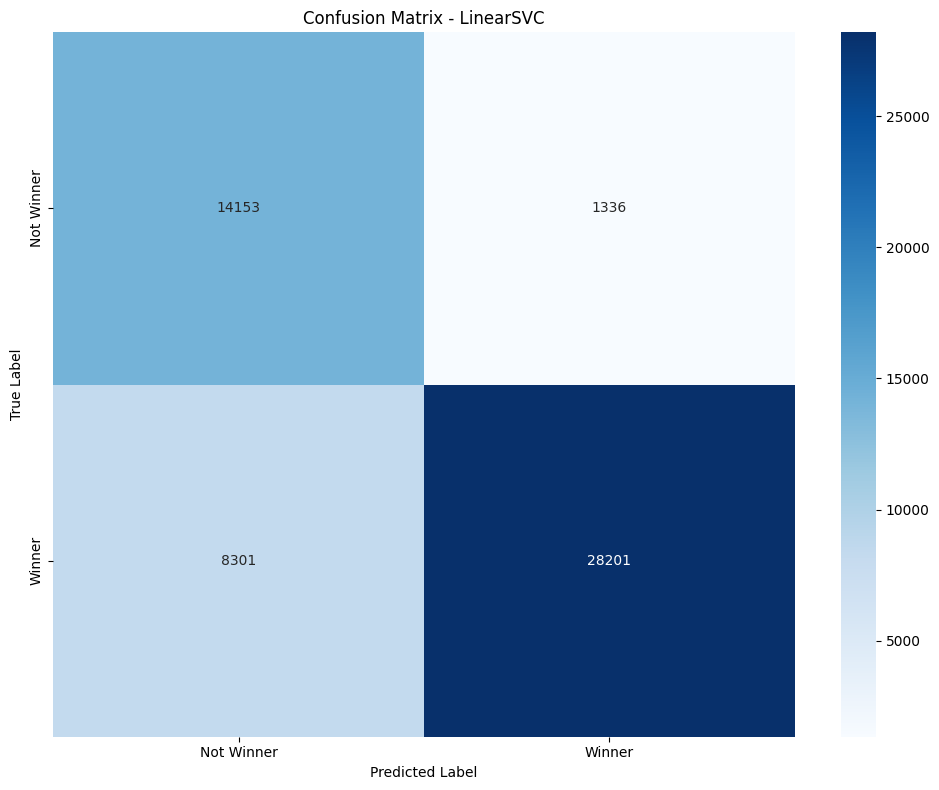

In [59]:
y_true = y_test
y_pred = y_pred_final
print(f"Metrics:")
print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
print("Precision:", round(precision_score(y_true, y_pred), 4))
print("Recall:", round(recall_score(y_true, y_pred), 4))
print("F1-Score:", round(f1_score(y_true, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_true, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
plt.figure(figsize=(10, 8))
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Winner', 'Winner'],
                yticklabels=['Not Winner', 'Winner'])
plt.title(f'Confusion Matrix - {'LinearSVC'}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [60]:
import joblib

filename = 'models_joblib/linear_svc_model.joblib'
joblib.dump(final_pipeline, filename)

['models_joblib/linear_svc_model.joblib']

In [61]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
   final_pipeline, 
    X_val, 
    y_val,
    n_repeats=2,
    random_state=42,
    scoring=['f1_weighted', 'precision_macro', 'recall_macro'],
    max_samples=0.5
)

Feature Importance Ranking for f1_weighted:
customer_win_rate: 0.1194 ± 0.0007
sphere_win_rate: 0.0574 ± 0.0008
Уровень: 0.0050 ± 0.0001
competitors_per_tender: 0.0019 ± 0.0000
region_win_rate: 0.0011 ± 0.0002
Тип торгов: 0.0006 ± 0.0000
total_wins: 0.0001 ± 0.0001
Снижение на торгах,%: -0.0001 ± 0.0000
Статус допуска: -0.0002 ± 0.0000
avg_competitors_in_sphere: -0.0002 ± 0.0000
avg_competitors_in_region: -0.0002 ± 0.0000
sphere_wins: -0.0002 ± 0.0000
region_wins: -0.0002 ± 0.0000
customer_wins: -0.0002 ± 0.0000
Обеспечение заявки (руб.): -0.0002 ± 0.0000
days_between: -0.0002 ± 0.0000
win_rate: -0.0002 ± 0.0000
log_profit: -0.0002 ± 0.0000
log_cost: -0.0002 ± 0.0000
avg_competitors_in_customer: -0.0002 ± 0.0000
Обеспечение заявки, %: -0.0002 ± 0.0000
is_jan_to_april: -0.0002 ± 0.0000
РНП ранее: -0.0002 ± 0.0000
is_2019: -0.0002 ± 0.0000
trade_end_night_12: -0.0002 ± 0.0000
app_start_night_12: -0.0002 ± 0.0000
app_end_noon_12: -0.0002 ± 0.0000
publication_peak_9_11: -0.0002 ± 0.0000
is

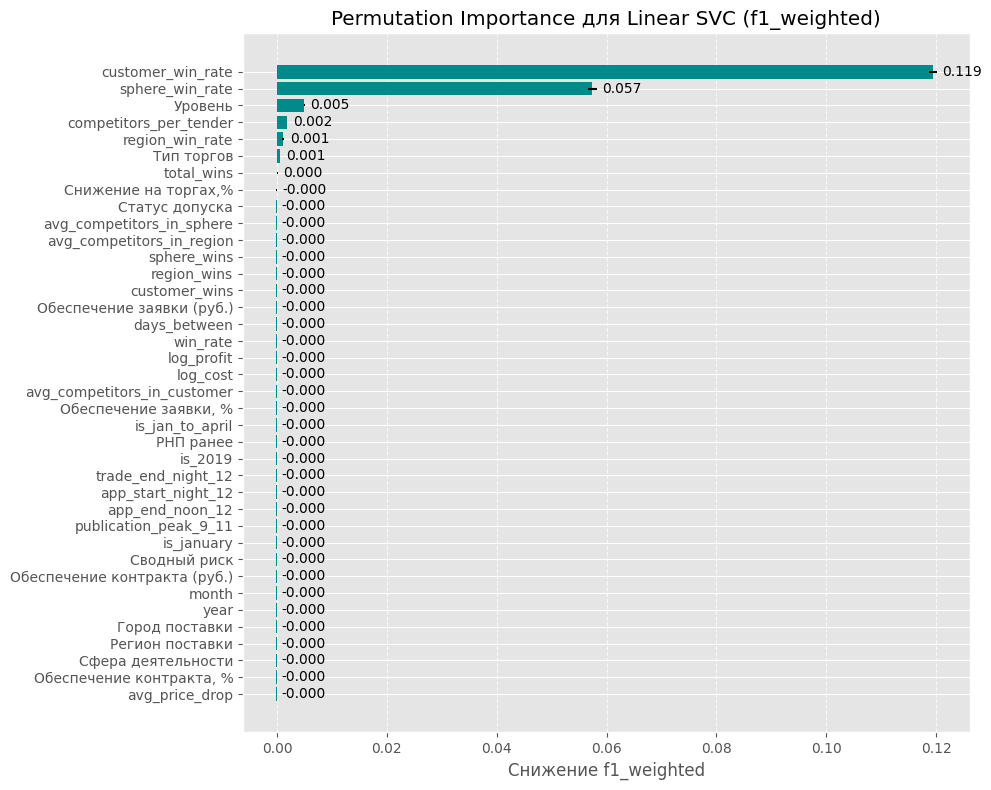

Feature Importance Ranking for precision_macro:
customer_win_rate: 0.1207 ± 0.0007
sphere_win_rate: 0.0580 ± 0.0008
Уровень: 0.0054 ± 0.0001
competitors_per_tender: 0.0017 ± 0.0000
region_win_rate: 0.0009 ± 0.0002
Тип торгов: 0.0008 ± 0.0000
total_wins: 0.0001 ± 0.0001
Снижение на торгах,%: -0.0001 ± 0.0000
Статус допуска: -0.0002 ± 0.0000
avg_competitors_in_sphere: -0.0002 ± 0.0000
avg_competitors_in_region: -0.0002 ± 0.0000
sphere_wins: -0.0002 ± 0.0000
region_wins: -0.0002 ± 0.0000
customer_wins: -0.0002 ± 0.0000
Обеспечение заявки (руб.): -0.0002 ± 0.0000
days_between: -0.0002 ± 0.0000
win_rate: -0.0002 ± 0.0000
log_profit: -0.0002 ± 0.0000
log_cost: -0.0002 ± 0.0000
avg_competitors_in_customer: -0.0002 ± 0.0000
Обеспечение заявки, %: -0.0002 ± 0.0000
is_jan_to_april: -0.0002 ± 0.0000
РНП ранее: -0.0002 ± 0.0000
is_2019: -0.0002 ± 0.0000
trade_end_night_12: -0.0002 ± 0.0000
app_start_night_12: -0.0002 ± 0.0000
app_end_noon_12: -0.0002 ± 0.0000
publication_peak_9_11: -0.0002 ± 0.000

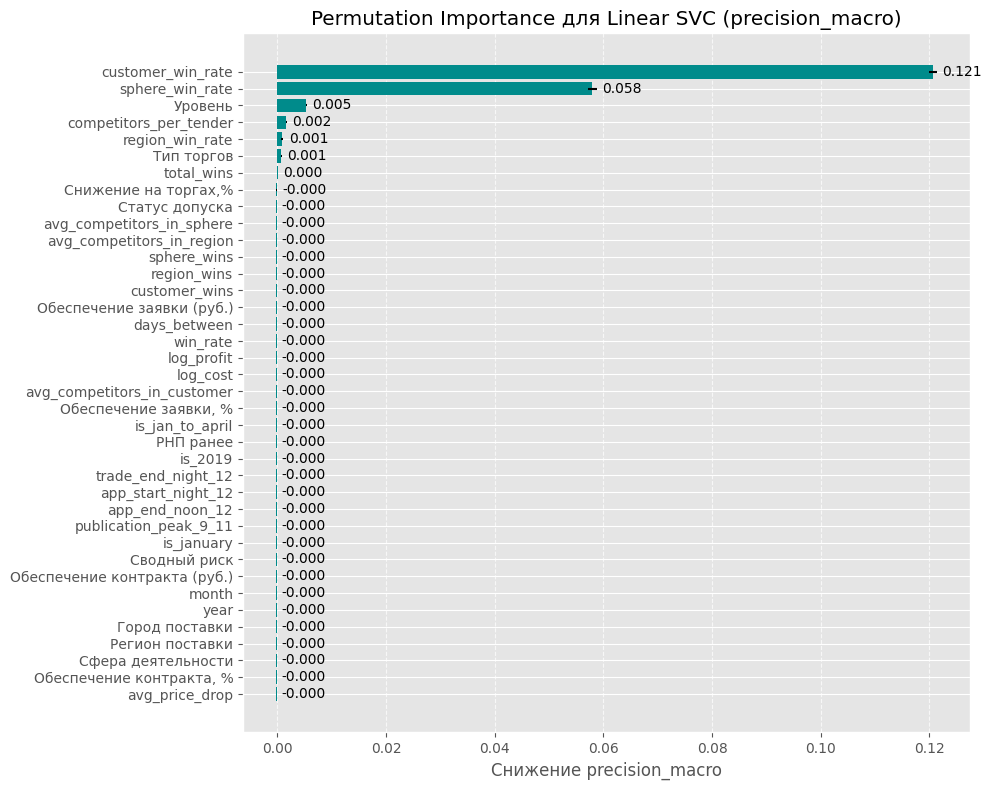

Feature Importance Ranking for recall_macro:
customer_win_rate: 0.1193 ± 0.0006
sphere_win_rate: 0.0578 ± 0.0008
Уровень: 0.0044 ± 0.0001
competitors_per_tender: 0.0021 ± 0.0000
region_win_rate: 0.0014 ± 0.0002
Тип торгов: 0.0004 ± 0.0000
total_wins: 0.0001 ± 0.0000
Снижение на торгах,%: -0.0000 ± 0.0000
Статус допуска: -0.0001 ± 0.0000
avg_competitors_in_sphere: -0.0001 ± 0.0000
avg_competitors_in_region: -0.0001 ± 0.0000
sphere_wins: -0.0001 ± 0.0000
region_wins: -0.0001 ± 0.0000
customer_wins: -0.0001 ± 0.0000
Обеспечение заявки (руб.): -0.0001 ± 0.0000
days_between: -0.0001 ± 0.0000
win_rate: -0.0001 ± 0.0000
log_profit: -0.0001 ± 0.0000
log_cost: -0.0001 ± 0.0000
avg_competitors_in_customer: -0.0001 ± 0.0000
Обеспечение заявки, %: -0.0001 ± 0.0000
is_jan_to_april: -0.0001 ± 0.0000
РНП ранее: -0.0001 ± 0.0000
is_2019: -0.0001 ± 0.0000
trade_end_night_12: -0.0001 ± 0.0000
app_start_night_12: -0.0001 ± 0.0000
app_end_noon_12: -0.0001 ± 0.0000
publication_peak_9_11: -0.0001 ± 0.0000
i

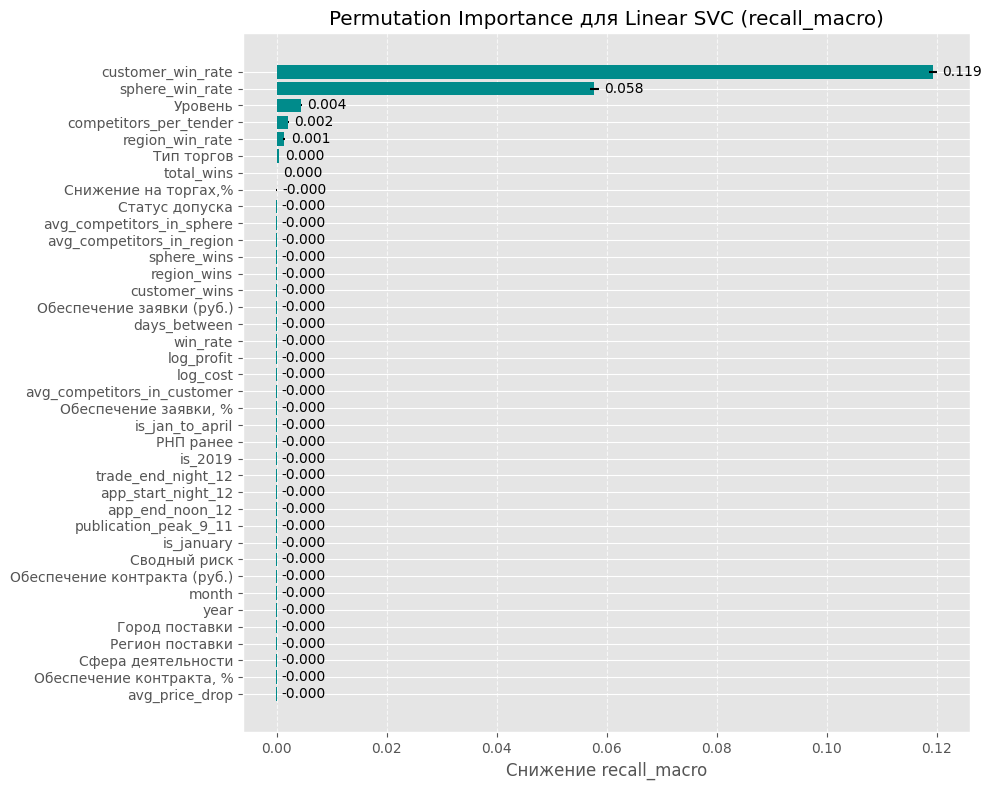

In [62]:
feature_names = X_val.columns

for metric, result in result.items():
    sorted_idx = result['importances_mean'].argsort()[::-1]

    print(f"Feature Importance Ranking for {metric}:")
    for i in sorted_idx:
        print(f"{feature_names[i]}: {result['importances_mean'][i]:.4f} ± {result['importances_std'][i]:.4f}")

    feat_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': result['importances_mean'],
        'importance_std': result['importances_std']
    })
    feat_df = feat_df.sort_values('importance_mean', ascending=True)

    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(10, 8))

    ax.barh(
        feat_df['feature'],
        feat_df['importance_mean'],
        xerr=feat_df['importance_std'],
        align='center',
        color='darkcyan'
    )
    ax.set_xlabel(f'Снижение {metric}')
    ax.set_title(f'Permutation Importance для Linear SVC ({metric})')
    ax.grid(axis='x', linestyle='--', alpha=0.7)

    for i, (mean, std) in enumerate(zip(feat_df['importance_mean'], feat_df['importance_std'])):
        ax.text(mean + std + 0.001, i, f"{mean:.3f}", va='center')

    plt.tight_layout()
    plt.show()

In [69]:
result

{'importances_mean': array([-1.13209570e-04, -1.13209570e-04, -1.13209570e-04, -1.87085682e-05,
        -1.13209570e-04,  1.40098727e-03,  1.19333246e-01,  5.77619828e-02,
        -1.13209570e-04, -1.13209570e-04, -1.13209570e-04, -1.13209570e-04,
         5.06406133e-05,  2.12296208e-03, -1.13209570e-04, -1.13209570e-04,
        -1.13209570e-04, -1.13209570e-04, -1.13209570e-04, -1.13209570e-04,
        -1.13209570e-04, -1.13209570e-04, -1.13209570e-04, -1.13209570e-04,
         4.40117273e-04,  4.44639522e-03, -1.13209570e-04, -1.13209570e-04,
        -1.13209570e-04, -1.13209570e-04, -1.13209570e-04, -1.13209570e-04,
        -1.13209570e-04, -1.13209570e-04, -1.13209570e-04, -1.13209570e-04,
        -1.13209570e-04, -1.13209570e-04]),
 'importances_std': array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.66894756e-05,
        0.00000000e+00, 1.94637855e-04, 6.43727127e-04, 8.48772927e-04,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        4.8550423

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat),
        ('pass', 'passthrough', binary_features)
    ],
    remainder='drop'
)

In [80]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C 
from sklearn.metrics import f1_score


def objective_gpc(trial):
    """Optuna objective function for GaussianProcessClassifier tuning."""

    length_scale = trial.suggest_float('kernel__length_scale', 1e-2, 1e2, log=True)
    kernel = C(1.0, "fixed") * RBF(length_scale=length_scale)

    gpc = GaussianProcessClassifier(
        kernel=kernel,
        random_state=42,
        n_restarts_optimizer=1 
    )

    pipeline_gpc = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', gpc)
    ])

    pipeline_gpc.fit(X_train, y_train)
    y_pred = pipeline_gpc.predict(X_val)
    score = f1_score(y_val, y_pred)  
    return score


study_gpc = optuna.create_study(direction='maximize')
n_trials_gpc = 30 
study_gpc.optimize(objective_gpc, n_trials=n_trials_gpc)

[I 2025-04-28 19:48:52,441] A new study created in memory with name: no-name-37046851-8756-4aa6-b16a-00232570ea05


: 